# Question 2 — Applied: Stepwise Selection and the Lasso on Simulated Data
**ISLP, Chapter 6, Applied Exercise 8 (p. 286)**

**Author:** Brandon Perkins  
**Course:** DDS-8555 Predictive Analysis — Week 3

---
We simulate data from a known polynomial model and then ask whether forward stepwise, backward stepwise,
and the lasso can recover the true structure from a dictionary of ten powers $X, X^2, \dots, X^{10}$.
Because the truth is known by construction, this is a controlled test of each selection method.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations
from sklearn.linear_model import LinearRegression, LassoCV, Lasso
from sklearn.preprocessing import StandardScaler

rng = np.random.default_rng(8555)     # seed tied to the course number
plt.rcParams.update({'figure.dpi':110,'axes.grid':True,'grid.alpha':0.3})
pd.set_option('display.float_format', lambda v: f'{v:0.4f}')
print("Ready.")

Ready.


## (a) Generate the predictor $X$ and noise $\varepsilon$ ($n = 100$)

In [2]:
n = 100
X   = rng.normal(size=n)
eps = rng.normal(scale=1.0, size=n)
print(f"X:   mean={X.mean():.3f}, sd={X.std():.3f}")
print(f"eps: mean={eps.mean():.3f}, sd={eps.std():.3f}")

X:   mean=-0.070, sd=0.895
eps: mean=-0.071, sd=0.959


## (b) Generate the response

$$Y = \beta_0 + \beta_1 X + \beta_2 X^2 + \beta_3 X^3 + \varepsilon$$

with the chosen constants $\beta_0 = 3$, $\beta_1 = 2$, $\beta_2 = -3$, $\beta_3 = 0.5$.

In [3]:
b0, b1, b2, b3 = 3.0, 2.0, -3.0, 0.5
Y = b0 + b1*X + b2*X**2 + b3*X**3 + eps

# Dictionary of candidate predictors X, X^2, ..., X^10
P = 10
cols = [f"X^{d}" for d in range(1, P+1)]
D = pd.DataFrame({f"X^{d}": X**d for d in range(1, P+1)})
print(f"True model: Y = {b0} + {b1}*X {b2}*X^2 + {b3}*X^3 + noise")
print("Candidate dictionary:", cols)
D.head()

True model: Y = 3.0 + 2.0*X -3.0*X^2 + 0.5*X^3 + noise
Candidate dictionary: ['X^1', 'X^2', 'X^3', 'X^4', 'X^5', 'X^6', 'X^7', 'X^8', 'X^9', 'X^10']


,X^1,X^2,X^3,X^4,X^5,X^6,X^7,X^8,X^9,X^10
0,0.9050,0.8189,0.7411,0.6707,0.6069,0.5492,0.4970,0.4498,0.4070,0.3683
1,-0.7869,0.6192,-0.4872,0.3834,-0.3017,0.2374,-0.1868,0.1470,-0.1157,0.0910
2,0.6650,0.4423,0.2941,0.1956,0.1301,0.0865,0.0575,0.0383,0.0254,0.0169
3,0.3340,0.1116,0.0373,0.0124,0.0042,0.0014,0.0005,0.0002,0.0001,0.0000
4,-0.2788,0.0777,-0.0217,0.0060,-0.0017,0.0005,-0.0001,0.0000,-0.0000,0.0000


### Helper functions: RSS and Mallow's $C_p$

Following the module notes, $C_p = \dfrac{\text{RSS} + 2 d \hat{\sigma}^2}{n}$, where $d$ is the number of
predictors in the model and $\hat{\sigma}^2$ is estimated from the full ten-predictor model. Lower is
better.

In [4]:
def rss_of(features, target, frame):
    features = list(features)
    if not features:
        return float(((target - target.mean())**2).sum())
    m = LinearRegression().fit(frame[features], target)
    return float(((target - m.predict(frame[features]))**2).sum())

def sigma2_full(target, frame):
    full = list(frame.columns)
    m = LinearRegression().fit(frame[full], target)
    resid = target - m.predict(frame[full])
    return float((resid**2).sum() / (len(target) - len(full) - 1))

def cp_stat(rss, d, s2, n):
    return (rss + 2*d*s2) / n

def forward_path(target, frame):
    cols_all = list(frame.columns); cur = []; path = {0: []}
    for k in range(1, len(cols_all)+1):
        cand = min((c for c in cols_all if c not in cur),
                   key=lambda c: rss_of(cur+[c], target, frame))
        cur = cur + [cand]; path[k] = cur.copy()
    return path

def backward_path(target, frame):
    cols_all = list(frame.columns); cur = cols_all.copy()
    path = {len(cols_all): cur.copy()}
    for k in range(len(cols_all)-1, -1, -1):
        drop = min(cur, key=lambda c: rss_of([x for x in cur if x != c], target, frame))
        cur = [x for x in cur if x != drop]; path[k] = cur.copy()
    return path

def summarize(path, target, frame, label):
    s2 = sigma2_full(target, frame); n_ = len(target); rows = []
    for k, feats in sorted(path.items()):
        r = rss_of(feats, target, frame)
        rows.append({'k': k, 'Cp': cp_stat(r, k, s2, n_), 'RSS': r,
                     'model': ', '.join(feats) if feats else '(intercept only)'})
    out = pd.DataFrame(rows)
    best = out.loc[out['Cp'].idxmin()]
    print(f"--- {label}: Cp selects k = {int(best['k'])} -> {best['model']} ---")
    return out, int(best['k']), path[int(best['k'])]
print("Helpers defined.")

Helpers defined.


## (c) Forward stepwise selection, model chosen by $C_p$

In [5]:
fpath = forward_path(Y, D)
ftab, fk, ffeat = summarize(fpath, Y, D, "FORWARD")
print(ftab.to_string(index=False))

--- FORWARD: Cp selects k = 5 -> X^2, X^1, X^3, X^4, X^6 ---
 k      Cp       RSS                                             model
 0 25.6197 2561.9684                                  (intercept only)
 1 11.2860 1126.7467                                               X^2
 2  1.9977  196.0655                                          X^2, X^1
 3  0.9338   87.8218                                     X^2, X^1, X^3
 4  0.9306   85.6547                                X^2, X^1, X^3, X^4
 5  0.9250   83.2405                           X^2, X^1, X^3, X^4, X^6
 6  0.9372   82.6117                      X^2, X^1, X^3, X^4, X^6, X^5
 7  0.9537   82.4092                 X^2, X^1, X^3, X^4, X^6, X^5, X^9
 8  0.9722   82.4082           X^2, X^1, X^3, X^4, X^6, X^5, X^9, X^10
 9  0.9908   82.4082      X^2, X^1, X^3, X^4, X^6, X^5, X^9, X^10, X^8
10  1.0093   82.4082 X^2, X^1, X^3, X^4, X^6, X^5, X^9, X^10, X^8, X^7


In [6]:
fmod = LinearRegression().fit(D[ffeat], Y)
fcoef = pd.DataFrame({'predictor': ffeat, 'coefficient': fmod.coef_})
print(f"Intercept: {fmod.intercept_:.4f}")
print(fcoef.to_string(index=False))

Intercept: 2.7607
predictor  coefficient
      X^2      -2.1007
      X^1       2.0676
      X^3       0.4901
      X^4      -0.4830
      X^6       0.0511


## (d) Backward stepwise selection, and comparison with (c)

In [7]:
bpath = backward_path(Y, D)
btab, bk, bfeat = summarize(bpath, Y, D, "BACKWARD")
print(btab.to_string(index=False))

bmod = LinearRegression().fit(D[bfeat], Y)
print(f"\nIntercept: {bmod.intercept_:.4f}")
print(pd.DataFrame({'predictor': bfeat, 'coefficient': bmod.coef_}).to_string(index=False))
print(f"\nForward  Cp model: {ffeat}")
print(f"Backward Cp model: {bfeat}")
print(f"Identical selection: {set(ffeat) == set(bfeat)}")

--- BACKWARD: Cp selects k = 5 -> X^1, X^2, X^3, X^4, X^6 ---
 k      Cp       RSS                                             model
 0 25.6197 2561.9684                                  (intercept only)
 1 11.2860 1126.7467                                               X^2
 2  1.9977  196.0655                                          X^1, X^2
 3  0.9338   87.8218                                     X^1, X^2, X^3
 4  0.9306   85.6547                                X^1, X^2, X^3, X^4
 5  0.9250   83.2405                           X^1, X^2, X^3, X^4, X^6
 6  0.9372   82.6117                      X^1, X^2, X^3, X^4, X^5, X^6
 7  0.9537   82.4092                 X^1, X^2, X^3, X^4, X^5, X^6, X^9
 8  0.9722   82.4082           X^1, X^2, X^3, X^4, X^5, X^6, X^9, X^10
 9  0.9908   82.4082      X^1, X^2, X^3, X^4, X^5, X^6, X^8, X^9, X^10
10  1.0093   82.4082 X^1, X^2, X^3, X^4, X^5, X^6, X^7, X^8, X^9, X^10

Intercept: 2.7607
predictor  coefficient
      X^1       2.0676
      X^2      -2.100

## (e) Lasso with cross-validated $\lambda$

The powers of $X$ differ enormously in scale ($X^{10}$ dwarfs $X$), and the lasso penalty is applied to
raw coefficient magnitudes. Standardizing the predictors is therefore **required**, exactly as the module
notes emphasize, so that the penalty treats every term comparably.

Optimal lambda (alpha) selected by 10-fold CV: 0.02298


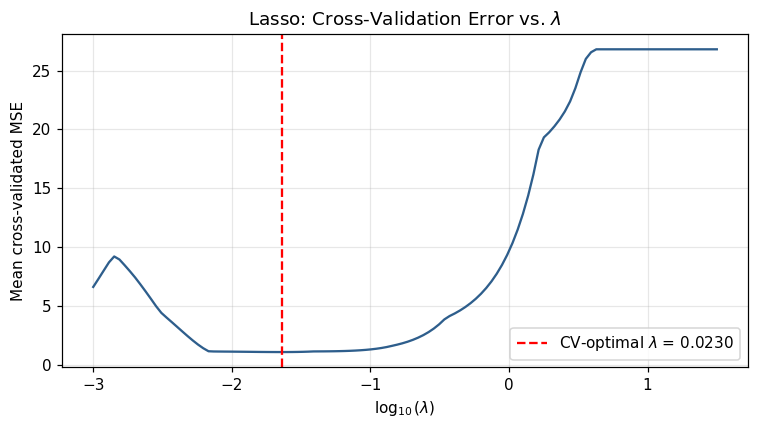

In [8]:
scaler = StandardScaler()
Ds = scaler.fit_transform(D)

lcv = LassoCV(alphas=np.logspace(-3, 1.5, 120), cv=10, max_iter=200000,
              random_state=8555).fit(Ds, Y)
print(f"Optimal lambda (alpha) selected by 10-fold CV: {lcv.alpha_:.5f}")

mse_path = lcv.mse_path_.mean(axis=1)
fig, ax = plt.subplots(figsize=(7,4))
ax.plot(np.log10(lcv.alphas_), mse_path, color='#2E5E8C')
ax.axvline(np.log10(lcv.alpha_), color='red', ls='--',
           label=f'CV-optimal $\\lambda$ = {lcv.alpha_:.4f}')
ax.set_xlabel(r'$\log_{10}(\lambda)$'); ax.set_ylabel('Mean cross-validated MSE')
ax.set_title('Lasso: Cross-Validation Error vs. $\\lambda$')
ax.legend(); plt.tight_layout(); plt.show()

In [9]:
lasso_coef = pd.DataFrame({'predictor': cols, 'coefficient': lcv.coef_})
lasso_coef['selected'] = lasso_coef['coefficient'].abs() > 1e-8
print(f"Intercept: {lcv.intercept_:.4f}")
print(lasso_coef.to_string(index=False))
print(f"\nNon-zero terms retained: {list(lasso_coef.loc[lasso_coef['selected'],'predictor'])}")

Intercept: 0.3044
predictor  coefficient  selected
      X^1       1.6976      True
      X^2      -3.3248      True
      X^3       1.7450      True
      X^4      -0.3622      True
      X^5       0.0000     False
      X^6      -0.0000     False
      X^7       0.0000     False
      X^8       0.0000     False
      X^9       0.0000     False
     X^10       0.0000     False

Non-zero terms retained: ['X^1', 'X^2', 'X^3', 'X^4']


## (f) A response driven by $X^7$ only

$$Y = \beta_0 + \beta_7 X^7 + \varepsilon, \qquad \beta_0 = 3,\ \beta_7 = 7$$

We repeat forward stepwise selection and the lasso on this new response.

In [10]:
b7 = 7.0
Y2 = b0 + b7*X**7 + eps

f2path = forward_path(Y2, D)
f2tab, f2k, f2feat = summarize(f2path, Y2, D, "FORWARD (Y2)")
print(f2tab.to_string(index=False))

f2mod = LinearRegression().fit(D[f2feat], Y2)
print(f"\nIntercept: {f2mod.intercept_:.4f}")
print(pd.DataFrame({'predictor': f2feat, 'coefficient': f2mod.coef_}).to_string(index=False))

--- FORWARD (Y2): Cp selects k = 2 -> X^7, X^6 ---
 k          Cp           RSS                                             model
 0 560990.3377 56099033.7740                                  (intercept only)
 1      0.9277       90.9196                                               X^7
 2      0.9045       86.7468                                          X^7, X^6
 3      0.9193       86.3714                                     X^7, X^6, X^2
 4      0.9077       83.3668                                X^7, X^6, X^2, X^4
 5      0.9202       82.7573                           X^7, X^6, X^2, X^4, X^3
 6      0.9378       82.6684                      X^7, X^6, X^2, X^4, X^3, X^9
 7      0.9538       82.4176                 X^7, X^6, X^2, X^4, X^3, X^9, X^1
 8      0.9722       82.4092            X^7, X^6, X^2, X^4, X^3, X^9, X^1, X^5
 9      0.9908       82.4082      X^7, X^6, X^2, X^4, X^3, X^9, X^1, X^5, X^10
10      1.0093       82.4082 X^7, X^6, X^2, X^4, X^3, X^9, X^1, X^5, X^10, X^8



In [11]:
Ds2 = StandardScaler().fit_transform(D)
lcv2 = LassoCV(alphas=np.logspace(-3, 3, 150), cv=10, max_iter=200000,
               random_state=8555).fit(Ds2, Y2)
c2 = pd.DataFrame({'predictor': cols, 'coefficient': lcv2.coef_})
c2['selected'] = c2['coefficient'].abs() > 1e-8
print(f"Optimal lambda: {lcv2.alpha_:.5f}   Intercept: {lcv2.intercept_:.4f}")
print(c2.to_string(index=False))
print(f"\nNon-zero terms retained: {list(c2.loc[c2['selected'],'predictor'])}")

Optimal lambda: 0.26068   Intercept: 23.1478
predictor  coefficient  selected
      X^1      -2.6574      True
      X^2      -0.0000     False
      X^3      -0.0000     False
      X^4      -1.3500      True
      X^5      83.1346      True
      X^6      -5.0275      True
      X^7     525.7077      True
      X^8      -0.0000     False
      X^9     147.8636      True
     X^10      -0.0000     False

Non-zero terms retained: ['X^1', 'X^4', 'X^5', 'X^6', 'X^7', 'X^9']


## Discussion of results

**Parts (c) and (d).** Both stepwise procedures traverse a dictionary of ten deterministic powers of $X$,
which are extremely collinear. Here the two searches converged on the **same five-term model**
($X, X^2, X^3, X^4, X^6$), even though forward and backward selection explore the model space from
opposite ends and are not guaranteed to agree. The $C_p$ curve is very flat between $k = 3$ and $k = 5$
(0.9338, 0.9306, 0.9250), so $C_p$ chose a model slightly **larger** than the true three-term generating
model, buying a marginal RSS improvement for two spurious terms. The recovered coefficients on the true
terms remain sensible ($\hat{\beta}_1 = 2.07$ against a true 2.0; $\hat{\beta}_3 = 0.49$ against a true
0.5), while $\hat{\beta}_2 = -2.10$ is pulled away from its true $-3.0$ because the redundant $X^4$ term
absorbs part of the curvature. This is a textbook demonstration that a penalized criterion controls
overfitting only approximately, and that collinear dictionaries distort individual coefficients even when
the overall fit is good.

**Part (e).** The lasso applies an $L_1$ penalty that shrinks coefficients and sets some exactly to zero,
performing selection and estimation in one step. Ten-fold cross-validation selected
$\lambda \approx 0.023$, and the fitted model retained $X, X^2, X^3, X^4$ while zeroing all six
higher-order powers. This is a **sparser and cleaner recovery than either stepwise search achieved**, and
it isolates the true cubic structure plus one extra term. Note that these coefficients are reported on the
standardized scale, so their magnitudes are not directly comparable to the original $\beta$ values. The
cross-validation curve is U-shaped: small $\lambda$ approaches least squares and overfits the collinear
dictionary, while large $\lambda$ over-shrinks toward the intercept-only model.

**Part (f).** With the response driven by a single high-order term, the two methods reversed their
standing, and the result runs **counter to the usual expectation that shrinkage handles collinearity
better**. Forward stepwise recovered the truth almost exactly, selecting $X^7$ first with an estimated
coefficient of 7.0026 against a true value of 7.0, and adding only $X^6$ with a negligible coefficient of
$-0.0066$. The lasso was markedly less sparse, retaining six terms ($X, X^4, X^5, X^6, X^7, X^9$). Two
factors explain this. First, $X^7$ produces an overwhelming single-variable RSS reduction, from
56,099,034 down to 90.9, so a greedy search cannot miss it. Second, standardizing an extremely
heavy-tailed variable such as $X^7$ leaves the neighbouring odd powers $X^5$ and $X^9$ almost perfectly
correlated with it, and the $L_1$ penalty responds by **distributing** the signal across those correlated
substitutes rather than concentrating it. Cross-validation then chose a relatively small $\lambda$
because that spread-out solution predicts well. The practical lesson is that the lasso's selection is
unstable when predictors are near-duplicates, a known limitation that motivates the elastic net, and that
no single selection method dominates across data-generating processes.

**Assumptions.** Linearity in the parameters and independent, identically distributed Gaussian errors hold
by construction, so the residual assumptions are satisfied by design. The assumption deliberately violated
is the absence of collinearity: the powers of $X$ are an extreme case of correlated predictors, which is
exactly what makes the contrast between parts (e) and (f) informative.

---
## Reference

James, G., Witten, D., Hastie, T., Tibshirani, R., & Taylor, J. (2023). *An introduction to statistical
learning with applications in Python*. Springer. https://doi.org/10.1007/978-3-031-38747-0